# Yates Algorithm for 2ᵏ Factorial Designs

The **Yates algorithm** efficiently computes all main effects and interactions in a 2ᵏ factorial experiment. Given observations in Yates standard order (−/+ for each factor), the algorithm produces all 2ᵏ effect estimates in k passes.

| Property | Value |
|---|---|
| **Input** | 2ᵏ observations in Yates standard order |
| **Output** | Mean, all main effects (A, B, C…), all interactions (AB, AC, BC, ABC…) |
| **Passes** | k passes, each: first half = sum pairs, second half = diff pairs |
| **Effect estimate** | Column result / (2^(k−1) × n_rep) |
| **Use** | Identify significant effects via half-normal plot |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

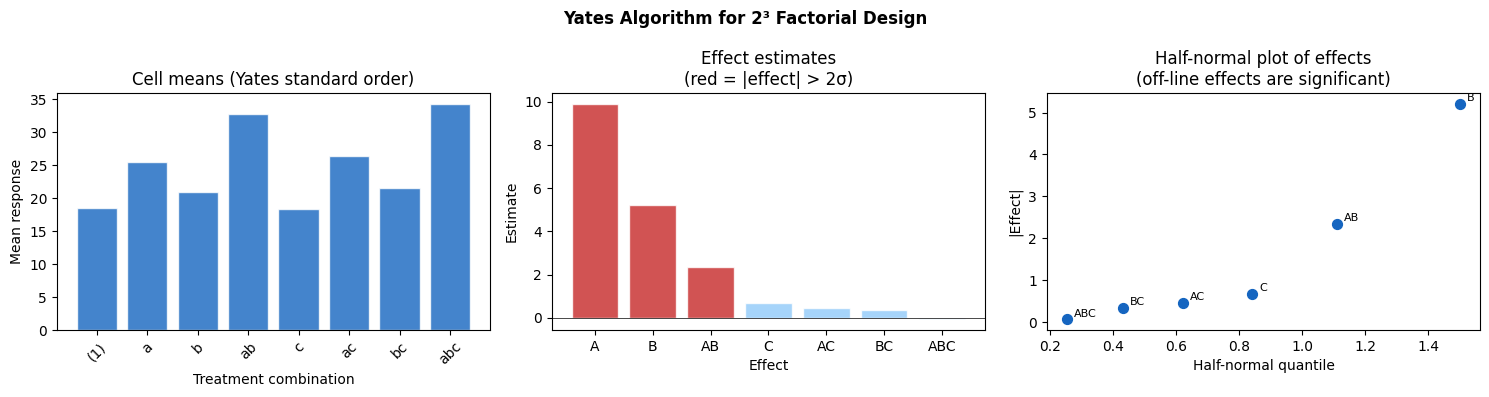

Yates algorithm output:
Effect  Label   Estimate    Yates_col
  Mean   Mean    49.5571     198.2283
     A      A     9.8990      39.5959
     B      B     5.2061      20.8246
    AB     AB     2.3530       9.4120
     C      C     0.6692       2.6769
    AC     AC     0.4528       1.8111
    BC     BC     0.3487       1.3949
   ABC    ABC    -0.0689      -0.2757


In [2]:
def yates_algorithm(y, k):
    n = 2**k
    result = y.copy().astype(float)
    for _ in range(k):
        temp = result.copy()
        for i in range(n//2):
            result[i]      = temp[2*i] + temp[2*i+1]
            result[n//2+i] = temp[2*i+1] - temp[2*i]
    return result

np.random.seed(42)

# 2^3 factorial: factors A (temp), B (pressure), C (catalyst)
# True effects: A=10, B=5, AB=3, C=2, rest=0
k = 3
n_rep = 3  # replicates per cell

# Yates order: (1), a, b, ab, c, ac, bc, abc
treatment_labels = ['(1)', 'a', 'b', 'ab', 'c', 'ac', 'bc', 'abc']
effect_labels = ['Mean', 'A', 'B', 'AB', 'C', 'AC', 'BC', 'ABC']

true_effects = np.array([50.0, 10.0, 5.0, 3.0, 2.0, 0.0, 0.0, 0.0])
# Convert effects to cell means
# Mean = 50, A contributes +/-10/2, B +/-5/2, etc.
A = np.array([-1,1,-1,1,-1,1,-1,1], dtype=float)
B = np.array([-1,-1,1,1,-1,-1,1,1], dtype=float)
AB = A*B
C = np.array([-1,-1,-1,-1,1,1,1,1], dtype=float)
AC = A*C; BC = B*C; ABC = A*B*C

X = np.column_stack([np.ones(8), A, B, AB, C, AC, BC, ABC])
cell_means = X @ (true_effects / np.array([2, 2, 2, 2, 2, 2, 2, 2]))  # effects are half-normal contrasts

# Simulate with replication
all_obs = []
for i in range(8):
    for _ in range(n_rep):
        all_obs.append(cell_means[i] + np.random.normal(0, 1.5))

# Yates from averages
y_avg = np.array([np.mean(all_obs[i*n_rep:(i+1)*n_rep]) for i in range(8)])
yates_out = yates_algorithm(y_avg, k)
effects = yates_out / (2**(k-1))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Yates Algorithm for 2³ Factorial Design', fontsize=12, fontweight='bold')

# Panel 1: cell means (bar chart)
axes[0].bar(range(8), y_avg, color='#1565C0', alpha=0.8, edgecolor='white')
axes[0].set_xticks(range(8)); axes[0].set_xticklabels(treatment_labels, rotation=45)
axes[0].set_title('Cell means (Yates standard order)')
axes[0].set_xlabel('Treatment combination'); axes[0].set_ylabel('Mean response')

# Panel 2: effect estimates
effect_vals = effects[1:]  # exclude mean
bar_colors = ['#C62828' if abs(e) > 2 else '#90CAF9' for e in effect_vals]
axes[1].bar(range(7), effect_vals, color=bar_colors, alpha=0.8, edgecolor='white')
axes[1].axhline(0, color='black', lw=0.5)
axes[1].set_xticks(range(7)); axes[1].set_xticklabels(effect_labels[1:])
axes[1].set_title('Effect estimates\n(red = |effect| > 2σ)')
axes[1].set_xlabel('Effect'); axes[1].set_ylabel('Estimate')

# Panel 3: half-normal plot of effects
abs_effects = np.sort(np.abs(effect_vals))
half_normal_q = stats.norm.ppf((np.arange(1, 8) + 0.5) / (2 * 7 + 1) + 0.5)
axes[2].scatter(half_normal_q, abs_effects, color='#1565C0', s=50, zorder=3)
# Label points
for i, (q, e, lab) in enumerate(zip(half_normal_q, abs_effects,
                                      [effect_labels[1+j] for j in np.argsort(np.abs(effect_vals))])):
    axes[2].annotate(lab, (q, e), textcoords='offset points', xytext=(5, 2), fontsize=8)
axes[2].set_title('Half-normal plot of effects\n(off-line effects are significant)')
axes[2].set_xlabel('Half-normal quantile'); axes[2].set_ylabel('|Effect|')

plt.tight_layout(); plt.show()

print('Yates algorithm output:')
print(f'{"Effect":>6} {"Label":>6} {"Estimate":>10} {"Yates_col":>12}')
for lab, est, yout in zip(effect_labels, effects, yates_out):
    print(f'{lab:>6} {lab:>6} {est:>10.4f} {yout:>12.4f}')

## Key Takeaways

| | |
|---|---|
| **Yates order** | (1), a, b, ab, c, ac, bc, abc — binary counting with + for high, − for low |
| **k passes** | Each pass: first half = sums, second half = differences of consecutive pairs |
| **Effect estimate** | Yates column / 2^(k−1) (or / n_rep·2^(k−1) with replication) |
| **Half-normal plot** | Effects on the line = noise; off the line = significant |
| **Sparsity of effects** | Typically few effects dominate — main effects and low-order interactions |
| **Extension** | Fractional factorials use subset of Yates order; resolution controls aliasing |